# Real Data Experiment: Year Prediction MSD — 10% Subset, Single Run

Compares 7 regression methods on the UCI Year Prediction MSD dataset.

**Experiment design:**
- Load full dataset (515,345 rows × 90 audio features → release year).
- Take the **first 10%** (~51,534 rows) as the working subset (dataset is too large for full run).
- Split the subset: **60% train / 20% calibration / 20% test**.
- Scaler fitted on the training set only (no leakage).

**Methods compared:** RF+Ridge · DNN · ResNet · DKL · DGP · MLKM · ResKernelNet

**Outputs:** Training curves · Method comparison · ACI Conformal prediction · Results table

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, sys, gc, resource, threading, random
import tracemalloc, ctypes

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import gpytorch
from gpytorch.models import ExactGP
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.distributions import MultivariateNormal
from gpytorch import variational

import psutil

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.9.1
CUDA available: False


In [2]:
# ── Data Loading: take 10% of full MSD ──────────────────────────────────────
data_path = '../../data/YearPredictionMSD/YearPredictionMSD.txt'
df_full   = pd.read_csv(data_path, header=None)

X_full = df_full.iloc[:, 1:].values.astype(np.float32)   # (515345, 90)
y_full = df_full.iloc[:, 0 ].values.astype(np.float32)   # (515345,)

# Take first 10%
N_SUBSET = int(0.10 * len(X_full))
X_sub    = X_full[:N_SUBSET]
y_sub    = y_full[:N_SUBSET]

print(f'Full dataset:  {X_full.shape[0]:,} × {X_full.shape[1]}')
print(f'10% subset:    {X_sub.shape[0]:,} × {X_sub.shape[1]}')
print(f'Year range:    {int(y_full.min())}–{int(y_full.max())}')

Full dataset:  515,345 × 90
10% subset:    51,534 × 90
Year range:    1922–2011


In [3]:
# ── Train / Calibration / Test split (60 / 20 / 20) ─────────────────────────
N = len(X_sub)
n_train = int(0.60 * N)
n_calib = int(0.20 * N)

train_x = X_sub[:n_train]
train_y = y_sub[:n_train]
calibration_x = X_sub[n_train:n_train + n_calib]
calibration_y = y_sub[n_train:n_train + n_calib]
test_x  = X_sub[n_train + n_calib:]
test_y  = y_sub[n_train + n_calib:]

# Standardise — fit on train only
x_scaler = preprocessing.StandardScaler()
train_x       = x_scaler.fit_transform(train_x)
calibration_x = x_scaler.transform(calibration_x)
test_x        = x_scaler.transform(test_x)

print(f'train:       {train_x.shape}')
print(f'calibration: {calibration_x.shape}')
print(f'test:        {test_x.shape}')

train:       (30920, 90)
calibration: (10306, 90)
test:        (10308, 90)


In [4]:
# ── Per-layer median-distance heuristic for gamma ────────────────────────────
# For RFF with W ~ N(0, gamma^2 I), the kernel is exp(-gamma^2/2 * ||x-y||^2).
# gamma = 1/sqrt(median_sqdist).
# Per-layer gammas for MLKM/ResKernelNet are computed before each model run.

def _compute_layer_gamma(X_np):
    """Compute median-heuristic gamma from a numpy array X (n x d).
    Uses a subsample of up to 2000 rows to keep O(n^2) cost manageable."""
    X = X_np[:2000]
    dists = np.sum((X[None,:,:] - X[:,None,:])**2, axis=-1)
    flat  = dists[np.triu_indices(len(X), k=1)]
    med_sq = float(np.median(flat))
    if med_sq < 1e-12:
        return 1.0
    return float(1.0 / np.sqrt(med_sq))

gamma_median = _compute_layer_gamma(train_x)
print(f'gamma_l1 (from train_x, d={train_x.shape[1]}):  {gamma_median:.6f}')
print('Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.')

gamma_l1 (from train_x, d=90):  0.091711
Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.


In [5]:
# ── NaN check ────────────────────────────────────────────────────────────────
print("NaNs in train_x:",       np.isnan(train_x).any())
print("NaNs in calibration_x:", np.isnan(calibration_x).any())
print("NaNs in test_x:",        np.isnan(test_x).any())

NaNs in train_x: False
NaNs in calibration_x: False
NaNs in test_x: False


In [ ]:
# ── Global hyperparameters ────────────────────────────────────────────────────
INPUT_DIM   = 90    # number of features in MSD
HIDDEN_DIM1 = 256
HIDDEN_DIM2 = 128
HIDDEN_DIM3 = 128

TRAINING_CONFIG = {
    'batch_size':        256,
    'max_epochs':        1000,
    'early_stop_window': 50,
    'lr':                1e-4,
    'momentum':          0.95,
    'weight_decay':      1e-3,
    'seed':              7199,
}

GRAD_CLIP = 1.0   # gradient clipping threshold
SEED      = TRAINING_CONFIG['seed']

RESULTS_DIR = 'msd_results_10pct'
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


In [7]:
# ── Dataset helper ────────────────────────────────────────────────────────────
class mydataset(Dataset):
    def __init__(self, x, y):
        self.x = x; self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# ── Reproducibility & measurement utilities ───────────────────────────────────
GLOBAL_SEED = SEED

def set_global_seed(seed=None):
    if seed is None: seed = GLOBAL_SEED
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)


def measure_time(func, *args, **kwargs):
    t0 = time.time()
    result = func(*args, **kwargs)
    return result, time.time() - t0


def _release_memory():
    gc.collect(); gc.collect(); gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception: pass


def measure_memory_cpu(func, *args, **kwargs):
    """Warm-up + measured run. Returns (result, delta_MB, peak_MB)."""
    _release_memory()
    try: func(*args, **kwargs)
    except Exception: pass
    _release_memory()

    process    = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss
    _hwm_factor = 1 if sys.platform == 'darwin' else 1024
    hwm_before  = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss

    peak_rss = [mem_before]; stop_evt = threading.Event()
    def _monitor():
        while not stop_evt.is_set():
            try:
                cur = process.memory_info().rss
                if cur > peak_rss[0]: peak_rss[0] = cur
            except Exception: pass
            stop_evt.wait(0.01)

    mon_thread = threading.Thread(target=_monitor, daemon=True)
    try: tracemalloc.stop()
    except Exception: pass
    tracemalloc.start()
    mon_thread.start()

    result    = func(*args, **kwargs)

    mem_after = process.memory_info().rss
    hwm_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    stop_evt.set(); mon_thread.join()
    if mem_after > peak_rss[0]: peak_rss[0] = mem_after
    _, peak_bytes_tm = tracemalloc.get_traced_memory(); tracemalloc.stop()

    peak_rss_mb = max((peak_rss[0] - mem_before) / 1024**2, 0.0)
    peak_tm_mb  = peak_bytes_tm / 1024**2
    peak_hwm_mb = max((hwm_after - hwm_before) * _hwm_factor / 1024**2, 0.0)
    peak_mb     = max(peak_rss_mb, peak_tm_mb, peak_hwm_mb)
    delta_mb    = (mem_after - mem_before) / 1024**2

    _release_memory()
    return result, delta_mb, peak_mb


def measure_memory_gpu(func, *args, **kwargs):
    """Peak GPU memory during func(). Returns (result, peak_MB or None)."""
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None
    torch.cuda.reset_peak_memory_stats()
    result  = func(*args, **kwargs)
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    return result, peak_mb

In [8]:
# ── Split Conformal Prediction ───────────────────────────────────────────────
# MSD is NOT a time series — standard split conformal is appropriate.

def conformal_split_net(net, device, X_cal, y_cal, X_te, y_te, alpha=0.05):
    """
    Standard split conformal prediction for a PyTorch net.
    Returns (coverage, avg_interval_length, q_hat).
    """
    net.eval()
    with torch.no_grad():
        cal_preds = net(torch.from_numpy(X_cal).float().to(device)).squeeze().cpu().numpy()
        te_preds  = net(torch.from_numpy(X_te).float().to(device)).squeeze().cpu().numpy()

    scores = np.abs(y_cal - cal_preds)
    m = len(scores)
    k = min(max(int(np.ceil((m + 1) * (1 - alpha))), 1), m)
    q_hat = float(np.sort(scores)[k - 1])

    covered = (te_preds - q_hat <= y_te) & (y_te <= te_preds + q_hat)
    coverage = float(np.mean(covered))
    return coverage, 2 * q_hat, q_hat


def conformal_split_ridge(cal_preds, y_cal, te_preds, y_te, alpha=0.05):
    """
    Standard split conformal prediction for a numpy predictor (RF+Ridge).
    Returns (coverage, avg_interval_length, q_hat).
    """
    scores = np.abs(y_cal - cal_preds)
    m = len(scores)
    k = min(max(int(np.ceil((m + 1) * (1 - alpha))), 1), m)
    q_hat = float(np.sort(scores)[k - 1])

    covered = (te_preds - q_hat <= y_te) & (y_te <= te_preds + q_hat)
    coverage = float(np.mean(covered))
    return coverage, 2 * q_hat, q_hat


In [9]:
# ── Random Fourier Feature ────────────────────────────────────────────────────
def _sample_1d(pdf, gamma):
    if pdf == 'G':
        return torch.randn(1) * gamma
    elif pdf == 'L':
        return torch.distributions.Laplace(torch.tensor([0.0]), torch.tensor([1.0])).sample() * gamma
    elif pdf == 'C':
        return torch.distributions.Cauchy(torch.tensor([0.0]), torch.tensor([1.0])).sample() * gamma

def _sample(pdf, gamma, d):
    return torch.tensor([_sample_1d(pdf, gamma) for _ in range(d)])

class RandomFourierFeature:
    """Random Fourier Feature mapping x (n,d) -> phi(x) (n,D)."""
    def __init__(self, d, D, kernel='G', gamma=1.0):
        self.d, self.D, self.gamma = d, D, gamma
        kernel = kernel.upper()
        if kernel not in ('G', 'L', 'C'):
            raise ValueError('kernel must be G, L, or C')
        self.kernel = kernel
        self.b = torch.rand(D) * 2 * torch.pi
        self.W = _sample(kernel, gamma, d * D).reshape(D, d)

    def transform(self, x):
        ones = torch.ones(len(x), device=x.device).reshape(1, -1)
        W = self.W.to(x.device)
        b = self.b.to(x.device)
        result = torch.sqrt(torch.tensor(2.0 / self.D, device=x.device)) * \
                 torch.cos(W @ x.T + b.reshape(-1, 1) * ones)
        return result.T

In [10]:
# ── Weight initialisation ─────────────────────────────────────────────────────
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.uniform_(m.weight, -0.1, 0.1)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

## 0. RF + Ridge

In [43]:
# ── RF + Ridge ────────────────────────────────────────────────────────────────
def run_rf_ridge(train_x, train_y, test_x, test_y,
                 calibration_x=None, calibration_y=None,
                 D=128, gamma=None, kernel='G', seed=7199):
    """RF + Ridge. Trains on train+calib combined, returns (train_mse, test_mse)."""
    g = gamma if gamma is not None else gamma_median
    set_global_seed(seed)
    rff = RandomFourierFeature(train_x.shape[1], D, kernel=kernel, gamma=g)

    if calibration_x is not None:
        total_x = np.vstack((train_x, calibration_x))
        total_y = np.hstack((train_y, calibration_y))
    else:
        total_x, total_y = train_x, train_y

    x_tr_t = torch.from_numpy(total_x).float()
    x_te_t = torch.from_numpy(test_x).float()
    with torch.no_grad():
        phi_tr = rff.transform(x_tr_t).numpy()
        phi_te = rff.transform(x_te_t).numpy()

    ridge = RidgeCV(alphas=[1e-4, 1e-3, 1e-2, 1e-1, 1.0],
                    cv=KFold(n_splits=5, shuffle=True, random_state=seed))
    ridge.fit(phi_tr, total_y)

    train_mse = mean_squared_error(total_y, ridge.predict(phi_tr))
    test_mse  = mean_squared_error(test_y,  ridge.predict(phi_te))
    return train_mse, test_mse


def rf_core():
    return run_rf_ridge(train_x, train_y, test_x, test_y,
                        calibration_x, calibration_y, D=128, seed=SEED)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

(rf_result, rf_delta_cpu_mb, rf_peak_cpu_mb), rf_time = measure_time(
    lambda: measure_memory_cpu(rf_core)
)
rf_train_mse, rf_test_mse = rf_result

print("RF train MSE:", rf_train_mse)
print("RF test MSE:",  rf_test_mse)
print("RF runtime (s):", rf_time)
print("RF CPU peak (MB):", rf_peak_cpu_mb)

RF train MSE: 90.39444732666016
RF test MSE: 108.05602264404297
RF runtime (s): 2.061807155609131
RF CPU peak (MB): 52.61377239227295


## 1. DNN

In [12]:
# ── DNN ───────────────────────────────────────────────────────────────────────
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM,   HIDDEN_DIM1)
        self.fc2 = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
        self.fc3 = nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256, max_epochs=1000, early_stop_window=50,
            lr=1e-4, momentum=0.95, weight_decay=1e-3,
            device=None, verbose=False, seed=7199):
    set_global_seed(seed)
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)

    net = Net().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr,
                          momentum=momentum, weight_decay=weight_decay)

    trainloss, testloss = [], []
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(net(x).squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            p_tr = net(torch.from_numpy(train_x).float().to(device)).squeeze().cpu().numpy()
            trainloss.append(mean_squared_error(train_y, p_tr))
            p_te = net(torch.from_numpy(test_x).float().to(device)).squeeze().cpu().numpy()
            testloss.append(mean_squared_error(test_y, p_te))

        if epoch > early_stop_window:
            if trainloss[-1] > max(trainloss[-early_stop_window:-1]):
                if verbose: print(f'DNN early stop @ epoch {epoch}')
                break
        if verbose and epoch % 100 == 0:
            print(f'epoch {epoch:4d}  train={trainloss[-1]:.4f}  test={testloss[-1]:.4f}')

    return trainloss[-1], testloss[-1], len(trainloss), net, optimizer, trainloss, testloss, device

In [13]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_peak_cpu_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)

dnn_train_mse, dnn_test_mse, dnn_epochs, dnn_net, dnn_optimizer, dnn_trainloss, dnn_testloss, dnn_device = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN epochs:", dnn_epochs)
print("DNN time:", dnn_time)
print("DNN GPU peak (MB):", dnn_peak_gpu_mb)
print("DNN CPU peak (MB):", dnn_peak_cpu_mb)

DNN train MSE: 73.31170654296875
DNN test MSE: 294.0677185058594
DNN epochs: 1000
DNN time: 465.4668290615082
DNN GPU peak (MB): None
DNN CPU peak (MB): 5.65625


## 2. ResNet

In [14]:
# ── ResNet ────────────────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.fc1  = nn.Linear(in_f, out_f)
        self.fc2  = nn.Linear(out_f, out_f)
        self.skip = nn.Identity() if in_f == out_f else nn.Linear(in_f, out_f)
    def forward(self, x):
        identity = self.skip(x)
        y = F.relu(self.fc1(x))
        y = self.fc2(y)
        return identity + y


class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.rblock1 = ResidualBlock(INPUT_DIM,   HIDDEN_DIM1)
        self.rblock2 = ResidualBlock(HIDDEN_DIM1, HIDDEN_DIM2)
        self.rblock3 = ResidualBlock(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4     = nn.Linear(HIDDEN_DIM3, 1)
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        x = self.rblock3(x)
        return self.fc4(x)


def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256, max_epochs=1000, early_stop_window=50,
               lr=1e-4, momentum=0.95, weight_decay=1e-3,
               device=None, verbose=False, seed=7199):
    set_global_seed(seed)
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)

    net = ResNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr,
                          momentum=momentum, weight_decay=weight_decay)

    trainloss, testloss = [], []
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(net(x).squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            p_tr = net(torch.from_numpy(train_x).float().to(device)).squeeze().cpu().numpy()
            trainloss.append(mean_squared_error(train_y, p_tr))
            p_te = net(torch.from_numpy(test_x).float().to(device)).squeeze().cpu().numpy()
            testloss.append(mean_squared_error(test_y, p_te))

        if epoch > early_stop_window:
            if trainloss[-1] > max(trainloss[-early_stop_window:-1]):
                if verbose: print(f'ResNet early stop @ epoch {epoch}')
                break
        if verbose and epoch % 100 == 0:
            print(f'epoch {epoch:4d}  train={trainloss[-1]:.4f}  test={testloss[-1]:.4f}')

    return trainloss[-1], testloss[-1], len(trainloss), net, optimizer, trainloss, testloss, device

In [15]:
def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((res_result, res_peak_gpu), res_delta_cpu, res_peak_cpu), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs, res_net, res_optimizer, res_trainloss, res_testloss, res_device = res_result

print("ResNet train MSE:", res_train_mse)
print("ResNet test MSE:",  res_test_mse)
print("ResNet epochs:", res_epochs)
print("ResNet time:", res_time)
print("ResNet GPU peak (MB):", res_peak_gpu)
print("ResNet CPU peak (MB):", res_peak_cpu)

ResNet train MSE: 77.58187103271484
ResNet test MSE: 147.12786865234375
ResNet epochs: 753
ResNet time: 545.7744340896606
ResNet GPU peak (MB): None
ResNet CPU peak (MB): 2.40625


## 2.5 DKL (Deep Kernel Learning)

In [16]:
# ── Deep Kernel Learning (DKL) ────────────────────────────────────────────────
class DKLFeatureExtractor(nn.Module):
    def __init__(self, in_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,    HIDDEN_DIM1), nn.ReLU(),
            nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2), nn.ReLU(),
            nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3), nn.ReLU(),
            nn.Linear(HIDDEN_DIM3, 2),
        )
    def forward(self, x):
        return self.net(x)


class DKLExactGP(ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module  = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel())
    def forward(self, x):
        feat  = self.feature_extractor(x)
        mean  = self.mean_module(feat)
        covar = self.covar_module(feat)
        return MultivariateNormal(mean, covar)


def run_dkl(train_x, train_y, test_x, test_y,
            training_iter=300, pred_batch=2048, seed=7199):
    set_global_seed(seed)
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)

    feat       = DKLFeatureExtractor(INPUT_DIM).to(device)
    likelihood = GaussianLikelihood().to(device)
    model      = DKLExactGP(train_x_t, train_y_t, likelihood, feat).to(device)

    model.train(); likelihood.train()
    optimizer = torch.optim.Adam([
        {'params': model.feature_extractor.parameters(), 'lr': 1e-3},
        {'params': model.covar_module.parameters()},
        {'params': model.mean_module.parameters()},
        {'params': likelihood.parameters()},
    ], lr=0.05)
    mll = ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        loss = -mll(model(train_x_t), train_y_t)
        loss.backward()
        optimizer.step()

    model.eval(); likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_tr = likelihood(model(train_x_t)).mean.cpu().numpy()
        chunks = []
        for i in range(0, len(test_x), pred_batch):
            xb = torch.from_numpy(test_x[i:i+pred_batch]).float().to(device)
            chunks.append(likelihood(model(xb)).mean.cpu())
        pred_te = torch.cat(chunks).numpy()

    train_mse = mean_squared_error(train_y, pred_tr)
    test_mse  = mean_squared_error(test_y,  pred_te)
    return train_mse, test_mse

In [17]:
def dkl_core():
    return run_dkl(train_x, train_y, test_x, test_y)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((dkl_result, dkl_peak_gpu), dkl_delta_cpu, dkl_peak_cpu), dkl_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dkl_core)
    )
)

dkl_train_mse, dkl_test_mse = dkl_result

print("DKL train MSE:", dkl_train_mse)
print("DKL test MSE:",  dkl_test_mse)
print("DKL time (s):", dkl_time)
print("DKL GPU peak (MB):", dkl_peak_gpu)
print("DKL CPU peak (MB):", dkl_peak_cpu)

/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forge

DKL train MSE: 6.432210445404053
DKL test MSE: 251.00543212890625
DKL time (s): 49235.43024420738
DKL GPU peak (MB): None
DKL CPU peak (MB): 7585.875


## 2.6 DGP (Deep Gaussian Process)

In [18]:
# ── Deep Gaussian Process (DGP) ───────────────────────────────────────────────
class DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, input_dims, output_dims, inducing_points):
        if output_dims is not None:
            batch_shape = torch.Size([output_dims])
        else:
            batch_shape = torch.Size([])

        var_dist  = variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=batch_shape)
        var_strat = variational.VariationalStrategy(
            self, inducing_points, var_dist, learn_inducing_locations=True)

        super().__init__(var_strat, input_dims, output_dims)
        self.mean_module  = ConstantMean(batch_shape=batch_shape)
        self.covar_module = ScaleKernel(
            RBFKernel(batch_shape=batch_shape, ard_num_dims=input_dims),
            batch_shape=batch_shape)

    def forward(self, x):
        return MultivariateNormal(self.mean_module(x), self.covar_module(x))


def run_dgp(train_x, train_y, test_x, test_y,
            training_iter=1000, batch_size=256,
            num_inducing=128, hidden_dim=5, pred_batch=1024, seed=7199):
    set_global_seed(seed)
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)

    class TwoLayerDGP(gpytorch.models.deep_gps.DeepGP):
        def __init__(self):
            super().__init__()
            ind1 = train_x_t[torch.randperm(train_x_t.size(0))[:num_inducing]]
            ind2 = torch.randn(num_inducing, hidden_dim).to(device)
            self.hidden_layer = DGPLayer(train_x_t.shape[1], hidden_dim, ind1)
            self.output_layer = DGPLayer(hidden_dim, None, ind2)
            self.likelihood   = GaussianLikelihood().to(device)
        def forward(self, inputs):
            return self.output_layer(self.hidden_layer(inputs))
        def predict(self, x):
            self.eval(); self.likelihood.eval()
            with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
                preds = self.likelihood(self(x))
                return preds.mean.mean(dim=0)

    dgp_model = TwoLayerDGP().to(device)
    dgp_model.train(); dgp_model.likelihood.train()
    optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)
    elbo = gpytorch.mlls.DeepApproximateMLL(
        gpytorch.mlls.VariationalELBO(dgp_model.likelihood, dgp_model,
                                      num_data=train_x_t.size(0)))

    for _ in range(training_iter):
        perm = torch.randperm(train_x_t.size(0), device=device)
        for j in range(0, train_x_t.size(0), batch_size):
            idx = perm[j:j+batch_size]
            optimizer.zero_grad()
            output = dgp_model(train_x_t[idx])
            loss = -elbo(output, train_y_t[idx])
            loss.backward()
            optimizer.step()

    pred_tr = dgp_model.predict(train_x_t).detach().cpu().numpy()
    # Batched test prediction
    chunks = []
    for i in range(0, len(test_x), pred_batch):
        xb = torch.from_numpy(test_x[i:i+pred_batch]).float().to(device)
        chunks.append(dgp_model.predict(xb).detach().cpu())
    pred_te = torch.cat(chunks).numpy()

    train_mse = mean_squared_error(train_y, pred_tr)
    test_mse  = mean_squared_error(test_y,  pred_te)
    return train_mse, test_mse

In [19]:
def dgp_core():
    return run_dgp(train_x, train_y, test_x, test_y)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((dgp_result, dgp_peak_gpu), dgp_delta_cpu, dgp_peak_cpu), dgp_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dgp_core)
    )
)

dgp_train_mse, dgp_test_mse = dgp_result

print("DGP train MSE:", dgp_train_mse)
print("DGP test MSE:",  dgp_test_mse)
print("DGP time (s):", dgp_time)
print("DGP GPU peak (MB):", dgp_peak_gpu)
print("DGP CPU peak (MB):", dgp_peak_cpu)

DGP train MSE: 70.71807861328125
DGP test MSE: 94.0875015258789
DGP time (s): 6919.308019399643
DGP GPU peak (MB): None
DGP CPU peak (MB): 1264.15625


## 3. MLKM

In [ ]:
# ── MLKM (Multi-Layer Kernel Machine) ─────────────────────────────────────────
def run_mlkm(train_x, train_y, test_x, test_y,
             D1=128, D2=128, D3=128,
             gammas=None,           # pre-computed (g1,g2,g3); skips internal computation
             batch_size=256, max_epochs=1000, early_stop_window=50,
             lr=1e-4, momentum=0.95, weight_decay=1e-3,
             device=None, verbose=False, seed=7199):
    set_global_seed(seed)
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)

    # Per-layer gammas
    if gammas is not None:
        gamma_l1, gamma_l2, gamma_l3 = gammas
    else:
        gamma_l1 = _compute_layer_gamma(train_x)
        with torch.no_grad():
            _rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
            _fc1  = nn.Linear(D1, HIDDEN_DIM1)
            _h1   = _fc1(_rff1.transform(torch.from_numpy(train_x).float())).numpy()
        gamma_l2 = _compute_layer_gamma(_h1)
        with torch.no_grad():
            _rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
            _fc2  = nn.Linear(D2, HIDDEN_DIM2)
            _h2   = _fc2(_rff2.transform(torch.from_numpy(_h1).float())).numpy()
        gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  MLKM per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    rff1 = RandomFourierFeature(INPUT_DIM,   D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)

    class KernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(D1, HIDDEN_DIM1)
            self.fc2 = nn.Linear(D2, HIDDEN_DIM2)
            self.fc3 = nn.Linear(D3, HIDDEN_DIM3)
            self.out = nn.Linear(HIDDEN_DIM3, 1)
        def forward(self, x):
            x = self.fc1(rff1.transform(x))
            x = self.fc2(rff2.transform(x))
            x = self.fc3(rff3.transform(x))
            return self.out(x)

    net = KernelNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr,
                          momentum=momentum, weight_decay=weight_decay)

    trainloss, testloss = [], []
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(net(x).squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            p_tr = net(torch.from_numpy(train_x).float().to(device)).squeeze().cpu().numpy()
            trainloss.append(mean_squared_error(train_y, p_tr))
            p_te = net(torch.from_numpy(test_x).float().to(device)).squeeze().cpu().numpy()
            testloss.append(mean_squared_error(test_y, p_te))

        if epoch > early_stop_window:
            if trainloss[-1] > max(trainloss[-early_stop_window:-1]):
                if verbose: print(f'MLKM early stop @ epoch {epoch}')
                break
        if verbose and epoch % 100 == 0:
            print(f'epoch {epoch:4d}  train={trainloss[-1]:.4f}  test={testloss[-1]:.4f}')

    return trainloss[-1], testloss[-1], len(trainloss), net, optimizer, trainloss, testloss, device

In [32]:
# Pre-compute per-layer gammas OUTSIDE memory measurement (fair comparison)
print('Pre-computing MLKM layer gammas...')
_mlkm_g1 = _compute_layer_gamma(train_x)
with torch.no_grad():
    _tmp_rff1 = RandomFourierFeature(INPUT_DIM, 128, kernel='G', gamma=_mlkm_g1)
    _tmp_fc1  = nn.Linear(128, HIDDEN_DIM1)
    _tmp_h1   = _tmp_fc1(_tmp_rff1.transform(torch.from_numpy(train_x).float())).numpy()
_mlkm_g2 = _compute_layer_gamma(_tmp_h1)
with torch.no_grad():
    _tmp_rff2 = RandomFourierFeature(HIDDEN_DIM1, 128, kernel='G', gamma=_mlkm_g2)
    _tmp_fc2  = nn.Linear(128, HIDDEN_DIM2)
    _tmp_h2   = _tmp_fc2(_tmp_rff2.transform(torch.from_numpy(_tmp_h1).float())).numpy()
_mlkm_g3 = _compute_layer_gamma(_tmp_h2)
mlkm_precomputed_gammas = (_mlkm_g1, _mlkm_g2, _mlkm_g3)
print(f'MLKM gammas: L1={_mlkm_g1:.4f}  L2={_mlkm_g2:.4f}  L3={_mlkm_g3:.4f}')
del _tmp_rff1, _tmp_rff2, _tmp_fc1, _tmp_fc2, _tmp_h1, _tmp_h2

def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y,
                    gammas=mlkm_precomputed_gammas, **TRAINING_CONFIG)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_peak_cpu), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

mlkm_train_mse, mlkm_test_mse, mlkm_epochs, mlkm_net, mlkm_optimizer, mlkm_trainloss, mlkm_testloss, mlkm_device = mlkm_result

print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test MSE:",  mlkm_test_mse)
print("MLKM epochs:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM GPU peak (MB):", mlkm_peak_gpu)
print("MLKM CPU peak (MB):", mlkm_peak_cpu)

Pre-computing MLKM layer gammas...
MLKM gammas: L1=0.0917  L2=1.4147  L3=1.9830
MLKM train MSE: 87.30219268798828
MLKM test MSE: 111.4923324584961
MLKM epochs: 453
MLKM time: 249.81314897537231
MLKM GPU peak (MB): None
MLKM CPU peak (MB): 4.359375


## 4. ResKernelNet

In [33]:
# ── ResKernelNet (Residual Kernel Machine) ────────────────────────────────────
def run_reskernelnet(train_x, train_y, test_x, test_y,
                     D1=128, D2=None, D3=None,
                     gammas=None,           # pre-computed (g1,g2,g3)
                     batch_size=256, max_epochs=1000, early_stop_window=50,
                     lr=1e-4, momentum=0.95, weight_decay=1e-3,
                     device=None, verbose=False, seed=7199):
    """
    ResKernelNet: block_l(x) = A_l x + Delta_l x + W_l phi_l(x)
    Note: D2 and D3 must equal HIDDEN_DIM1 and HIDDEN_DIM2 for residual connections.
    """
    set_global_seed(seed)
    if D2 is None: D2 = HIDDEN_DIM1
    if D3 is None: D3 = HIDDEN_DIM2
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)

    # Per-layer gammas
    if gammas is not None:
        gamma_l1, gamma_l2, gamma_l3 = gammas
    else:
        gamma_l1 = _compute_layer_gamma(train_x)
        with torch.no_grad():
            _rff1   = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
            _A1     = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
            _W1     = nn.Linear(D1, HIDDEN_DIM1)
            _Delta1 = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
            nn.init.zeros_(_Delta1.weight)
            _x_t    = torch.from_numpy(train_x).float()
            _h1     = (_A1(_x_t) + _Delta1(_x_t) + _W1(_rff1.transform(_x_t))).numpy()
        gamma_l2 = _compute_layer_gamma(_h1)
        with torch.no_grad():
            _rff2   = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
            _A2     = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                       if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
            _W2     = nn.Linear(D2, HIDDEN_DIM2)
            _Delta2 = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
            nn.init.zeros_(_Delta2.weight)
            _h1_t   = torch.from_numpy(_h1).float()
            _h2     = (_A2(_h1_t) + _Delta2(_h1_t) + _W2(_rff2.transform(_h1_t))).numpy()
        gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  RKN per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    rff1 = RandomFourierFeature(INPUT_DIM,   D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)

    class ResKernelBlock(nn.Module):
        def __init__(self, d_in, d_phi, d_out, rff):
            super().__init__()
            self.rff   = rff
            self.W     = nn.Linear(d_phi, d_out)
            self.A     = nn.Identity() if d_in == d_out else nn.Linear(d_in, d_out, bias=False)
            self.Delta = nn.Linear(d_in, d_out, bias=False)
            nn.init.zeros_(self.Delta.weight)
        def forward(self, x):
            return self.A(x) + self.Delta(x) + self.W(self.rff.transform(x))

    class ResKernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.b1  = ResKernelBlock(INPUT_DIM,   D1, HIDDEN_DIM1, rff1)
            self.b2  = ResKernelBlock(HIDDEN_DIM1, D2, HIDDEN_DIM2, rff2)
            self.b3  = ResKernelBlock(HIDDEN_DIM2, D3, HIDDEN_DIM3, rff3)
            self.out = nn.Linear(HIDDEN_DIM3, 1)
        def forward(self, x):
            return self.out(self.b3(self.b2(self.b1(x))))

    net = ResKernelNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr,
                          momentum=momentum, weight_decay=weight_decay)

    trainloss, testloss = [], []
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(net(x).squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            p_tr = net(torch.from_numpy(train_x).float().to(device)).squeeze().cpu().numpy()
            trainloss.append(mean_squared_error(train_y, p_tr))
            p_te = net(torch.from_numpy(test_x).float().to(device)).squeeze().cpu().numpy()
            testloss.append(mean_squared_error(test_y, p_te))

        if epoch > early_stop_window:
            if trainloss[-1] > max(trainloss[-early_stop_window:-1]):
                if verbose: print(f'ResKernelNet early stop @ epoch {epoch}')
                break
        if verbose and epoch % 100 == 0:
            print(f'epoch {epoch:4d}  train={trainloss[-1]:.4f}  test={testloss[-1]:.4f}')

    return trainloss[-1], testloss[-1], len(trainloss), net, optimizer, trainloss, testloss, device

In [34]:
# Pre-compute per-layer gammas OUTSIDE memory measurement
print('Pre-computing ResKernelNet layer gammas...')
_D1_rkn = 128
_rkn_g1 = _compute_layer_gamma(train_x)
with torch.no_grad():
    _tmp_rff1 = RandomFourierFeature(INPUT_DIM, _D1_rkn, kernel='G', gamma=_rkn_g1)
    _tmp_A1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
    _tmp_W1   = nn.Linear(_D1_rkn, HIDDEN_DIM1)
    _tmp_D1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False); nn.init.zeros_(_tmp_D1.weight)
    _tmp_xt   = torch.from_numpy(train_x).float()
    _tmp_h1   = (_tmp_A1(_tmp_xt) + _tmp_D1(_tmp_xt) + _tmp_W1(_tmp_rff1.transform(_tmp_xt))).numpy()
_rkn_g2 = _compute_layer_gamma(_tmp_h1)
with torch.no_grad():
    _tmp_rff2 = RandomFourierFeature(HIDDEN_DIM1, HIDDEN_DIM1, kernel='G', gamma=_rkn_g2)
    _tmp_A2   = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                 if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
    _tmp_W2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
    _tmp_D2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False); nn.init.zeros_(_tmp_D2.weight)
    _tmp_h1t  = torch.from_numpy(_tmp_h1).float()
    _tmp_h2   = (_tmp_A2(_tmp_h1t) + _tmp_D2(_tmp_h1t) + _tmp_W2(_tmp_rff2.transform(_tmp_h1t))).numpy()
_rkn_g3 = _compute_layer_gamma(_tmp_h2)
rkn_precomputed_gammas = (_rkn_g1, _rkn_g2, _rkn_g3)
print(f'RKN gammas:  L1={_rkn_g1:.4f}  L2={_rkn_g2:.4f}  L3={_rkn_g3:.4f}')
del _tmp_rff1, _tmp_rff2, _tmp_A1, _tmp_A2, _tmp_W1, _tmp_W2, _tmp_D1, _tmp_D2, _tmp_h1, _tmp_h2, _tmp_xt, _tmp_h1t

def reskernelnet_core():
    return run_reskernelnet(train_x, train_y, test_x, test_y,
                            gammas=rkn_precomputed_gammas, **TRAINING_CONFIG)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

((rkn_result, rkn_peak_gpu), rkn_delta_cpu, rkn_peak_cpu), rkn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(reskernelnet_core)
    )
)

rkn_train_mse, rkn_test_mse, rkn_epochs, rkn_net, rkn_optimizer, rkn_trainloss, rkn_testloss, rkn_device = rkn_result

print("ResKernelNet train MSE:", rkn_train_mse)
print("ResKernelNet test MSE:",  rkn_test_mse)
print("ResKernelNet epochs:", rkn_epochs)
print("ResKernelNet time (s):", rkn_time)
print("ResKernelNet GPU peak (MB):", rkn_peak_gpu)
print("ResKernelNet CPU peak (MB):", rkn_peak_cpu)

Pre-computing ResKernelNet layer gammas...
RKN gammas:  L1=0.0917  L2=0.0936  L3=0.2275
ResKernelNet train MSE: 92.04107666015625
ResKernelNet test MSE: 110.97771453857422
ResKernelNet epochs: 647
ResKernelNet time (s): 617.2269840240479
ResKernelNet GPU peak (MB): None
ResKernelNet CPU peak (MB): 14.921875


## Training Curves: Epoch vs MSE

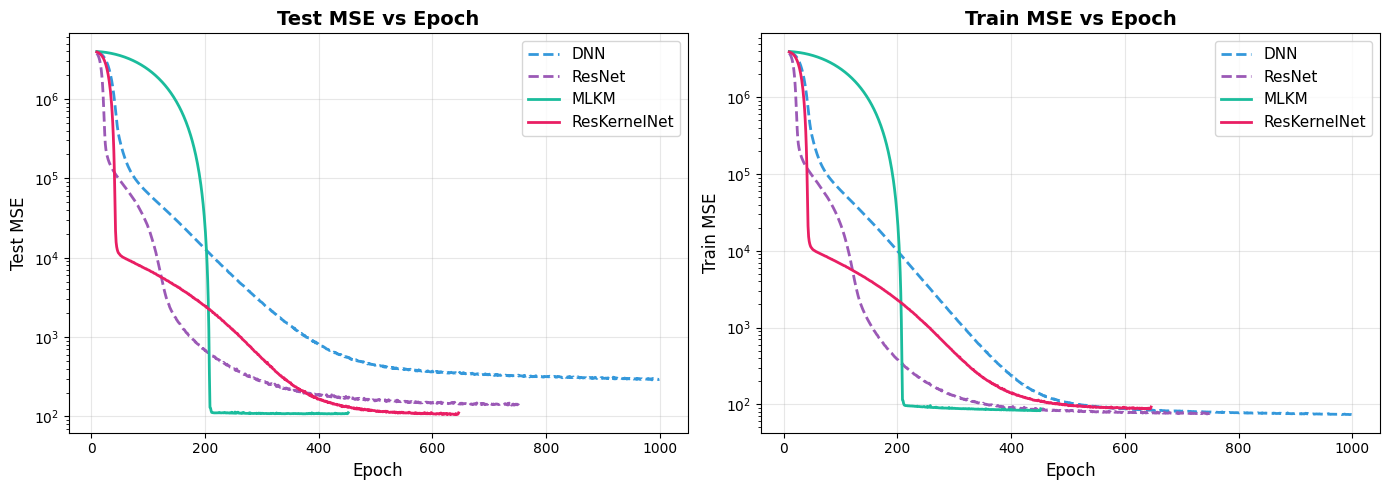

Epochs run — DNN=1000, ResNet=753, MLKM=453, ResKernelNet=647


In [35]:
# Training Curves for DNN, ResNet, MLKM, ResKernelNet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods_curves = {
    'DNN':          {'train': dnn_trainloss,  'test': dnn_testloss,  'color': '#3498db', 'ls': '--'},
    'ResNet':       {'train': res_trainloss,  'test': res_testloss,  'color': '#9b59b6', 'ls': '--'},
    'MLKM':         {'train': mlkm_trainloss, 'test': mlkm_testloss, 'color': '#1abc9c', 'ls': '-'},
    'ResKernelNet': {'train': rkn_trainloss,  'test': rkn_testloss,  'color': '#e91e63', 'ls': '-'},
}

skip_epochs = 10

ax1 = axes[0]
for name, data in methods_curves.items():
    epochs = range(skip_epochs, len(data['test']))
    ax1.plot(epochs, data['test'][skip_epochs:],
             label=name, color=data['color'], linestyle=data['ls'], linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12); ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11); ax1.set_yscale('log'); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for name, data in methods_curves.items():
    epochs = range(skip_epochs, len(data['train']))
    ax2.plot(epochs, data['train'][skip_epochs:],
             label=name, color=data['color'], linestyle=data['ls'], linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12); ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11); ax2.set_yscale('log'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Epochs run — DNN={len(dnn_trainloss)}, ResNet={len(res_trainloss)}, MLKM={len(mlkm_trainloss)}, ResKernelNet={len(rkn_trainloss)}")

## Conformal Prediction (Standard Split)

In [36]:
# ── Split Conformal Prediction for all methods ───────────────────────────────
TARGET_ALPHA = 0.05

conformal_results = {}

# Neural methods
_net_methods = {
    'DNN':          (dnn_net,  dnn_device),
    'ResNet':       (res_net,  res_device),
    'MLKM':         (mlkm_net, mlkm_device),
    'ResKernelNet': (rkn_net,  rkn_device),
}

for name, (net, dev) in _net_methods.items():
    cov, ivl, q = conformal_split_net(
        net, dev,
        calibration_x, calibration_y,
        test_x, test_y,
        alpha=TARGET_ALPHA
    )
    conformal_results[name] = {'coverage': cov, 'interval': ivl, 'q_hat': q}
    print(f'{name:15s}  coverage={cov:.3f}  avg_interval={ivl:.4f}  q_hat={q:.4f}')

# RF+Ridge: refit on train only for conformal scores
set_global_seed(SEED)
_rff_cf   = RandomFourierFeature(d=train_x.shape[1], D=500, kernel='G', gamma=gamma_median)
_ridge_cf = Ridge(alpha=0.01)
_ridge_cf.fit(_rff_cf.transform(torch.from_numpy(train_x).float()).numpy(), train_y)

_cal_preds = _ridge_cf.predict(_rff_cf.transform(torch.from_numpy(calibration_x).float()).numpy())
_te_preds  = _ridge_cf.predict(_rff_cf.transform(torch.from_numpy(test_x).float()).numpy())

cov, ivl, q = conformal_split_ridge(_cal_preds, calibration_y, _te_preds, test_y, alpha=TARGET_ALPHA)
conformal_results['RF+Ridge'] = {'coverage': cov, 'interval': ivl, 'q_hat': q}
print(f'RF+Ridge        coverage={cov:.3f}  avg_interval={ivl:.4f}  q_hat={q:.4f}')

# DKL / DGP: mark as N/A
for name in ['DKL', 'DGP']:
    conformal_results[name] = {'coverage': float('nan'), 'interval': float('nan'), 'q_hat': float('nan')}
    print(f'{name:15s}  conformal N/A (GP posterior uncertainty)')


DNN              coverage=0.927  avg_interval=40.5537  q_hat=20.2769
ResNet           coverage=0.930  avg_interval=40.8665  q_hat=20.4332
MLKM             coverage=0.937  avg_interval=39.7832  q_hat=19.8916
ResKernelNet     coverage=0.933  avg_interval=40.2932  q_hat=20.1466
RF+Ridge        coverage=0.930  avg_interval=37.8298  q_hat=18.9149
DKL              conformal N/A (GP posterior uncertainty)
DGP              conformal N/A (GP posterior uncertainty)


## Results: Comparison Table & Visualisation

In [44]:
# ── Comparison Table ─────────────────────────────────────────────────────────
_rows = [
    {
        'Method':        'RF+Ridge',
        'Train MSE':     rf_train_mse,
        'Test MSE':      rf_test_mse,
        'Time (s)':      rf_time,
        'CPU Δ (MB)':    rf_delta_cpu_mb,
        'CPU Peak (MB)': rf_peak_cpu_mb,
        'Conf. Coverage':conformal_results['RF+Ridge']['coverage'],
        'Conf. Interval':conformal_results['RF+Ridge']['interval'],
    },
    {
        'Method':        'DNN',
        'Train MSE':     dnn_train_mse,
        'Test MSE':      dnn_test_mse,
        'Time (s)':      dnn_time,
        'CPU Δ (MB)':    dnn_delta_cpu_mb,
        'CPU Peak (MB)': dnn_peak_cpu_mb,
        'Conf. Coverage':conformal_results['DNN']['coverage'],
        'Conf. Interval':conformal_results['DNN']['interval'],
    },
    {
        'Method':        'ResNet',
        'Train MSE':     res_train_mse,
        'Test MSE':      res_test_mse,
        'Time (s)':      res_time,
        'CPU Δ (MB)':    res_delta_cpu,
        'CPU Peak (MB)': res_peak_cpu,
        'Conf. Coverage':conformal_results['ResNet']['coverage'],
        'Conf. Interval':conformal_results['ResNet']['interval'],
    },
    {
        'Method':        'DKL',
        'Train MSE':     dkl_train_mse,
        'Test MSE':      dkl_test_mse,
        'Time (s)':      dkl_time,
        'CPU Δ (MB)':    dkl_delta_cpu,
        'CPU Peak (MB)': dkl_peak_cpu,
        'Conf. Coverage':float('nan'),
        'Conf. Interval':float('nan'),
    },
    {
        'Method':        'DGP',
        'Train MSE':     dgp_train_mse,
        'Test MSE':      dgp_test_mse,
        'Time (s)':      dgp_time,
        'CPU Δ (MB)':    dgp_delta_cpu,
        'CPU Peak (MB)': dgp_peak_cpu,
        'Conf. Coverage':float('nan'),
        'Conf. Interval':float('nan'),
    },
    {
        'Method':        'MLKM',
        'Train MSE':     mlkm_train_mse,
        'Test MSE':      mlkm_test_mse,
        'Time (s)':      mlkm_time,
        'CPU Δ (MB)':    mlkm_delta_cpu,
        'CPU Peak (MB)': mlkm_peak_cpu,
        'Conf. Coverage':conformal_results['MLKM']['coverage'],
        'Conf. Interval':conformal_results['MLKM']['interval'],
    },
    {
        'Method':        'ResKernelNet',
        'Train MSE':     rkn_train_mse,
        'Test MSE':      rkn_test_mse,
        'Time (s)':      rkn_time,
        'CPU Δ (MB)':    rkn_delta_cpu,
        'CPU Peak (MB)': rkn_peak_cpu,
        'Conf. Coverage':conformal_results['ResKernelNet']['coverage'],
        'Conf. Interval':conformal_results['ResKernelNet']['interval'],
    },
]

results_df = pd.DataFrame(_rows).set_index('Method')

print('=' * 85)
print('  MSD (10% subset) — Method Comparison  (HIDDEN=(256,128,64), D=128, per-layer gamma)')
print('=' * 85)
print(results_df.to_string(float_format=lambda x: f'{x:.5f}'))
print()

best_test = results_df['Test MSE'].idxmin()
best_ivl  = results_df['Conf. Interval'].dropna().idxmin()
print(f'  Best Test MSE:   {best_test} ({results_df.loc[best_test,"Test MSE"]:.5f})')
print(f'  Shortest CI:     {best_ivl}  ({results_df.loc[best_ivl,"Conf. Interval"]:.4f})')

results_df.to_csv(os.path.join(RESULTS_DIR, 'comparison_table.csv'))
print(f'\nSaved -> {RESULTS_DIR}/comparison_table.csv')

  MSD (10% subset) — Method Comparison  (HIDDEN=(256,128,64), D=128, per-layer gamma)
              Train MSE  Test MSE    Time (s)  CPU Δ (MB)  CPU Peak (MB)  Conf. Coverage  Conf. Interval
Method                                                                                                  
RF+Ridge       90.39445 108.05602     2.06181     1.12500       52.61377         0.93025        37.82983
DNN            73.31171 294.06772   465.46683  -223.00000        5.65625         0.92676        40.55371
ResNet         77.58187 147.12787   545.77443  -229.00000        2.40625         0.92986        40.86646
DKL             6.43221 251.00543 49235.43024  3182.46875     7585.87500             NaN             NaN
DGP            70.71808  94.08750  6919.30802  -594.59375     1264.15625             NaN             NaN
MLKM           87.30219 111.49233   249.81315  -254.79688        4.35938         0.93685        39.78320
ResKernelNet   92.04108 110.97771   617.22698  -267.98438       14.92188  

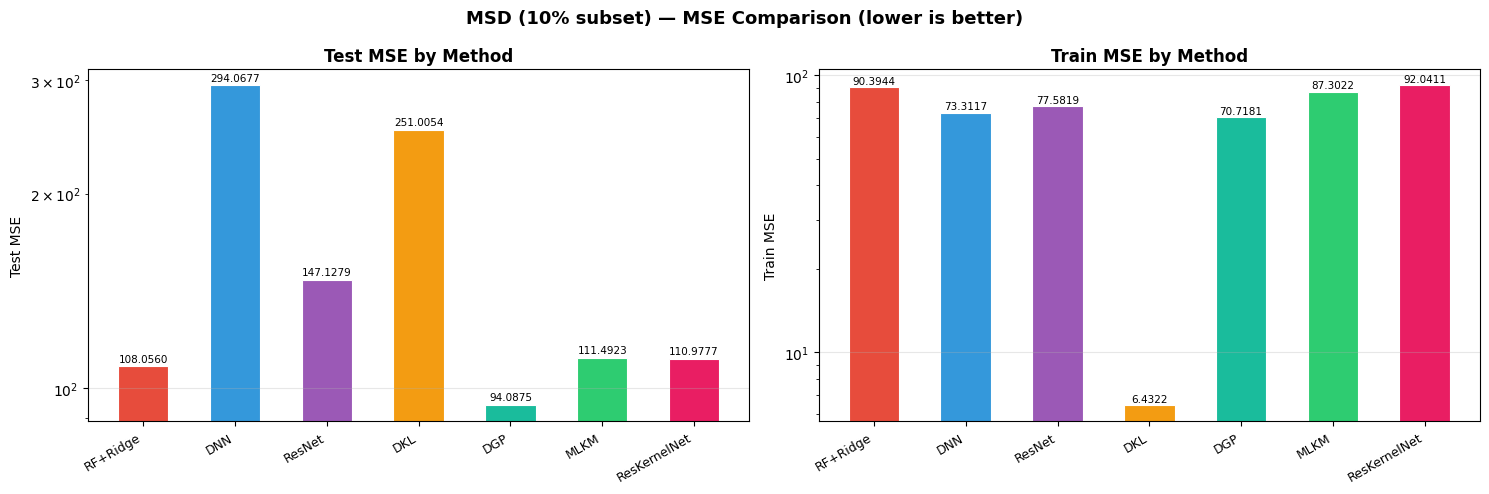

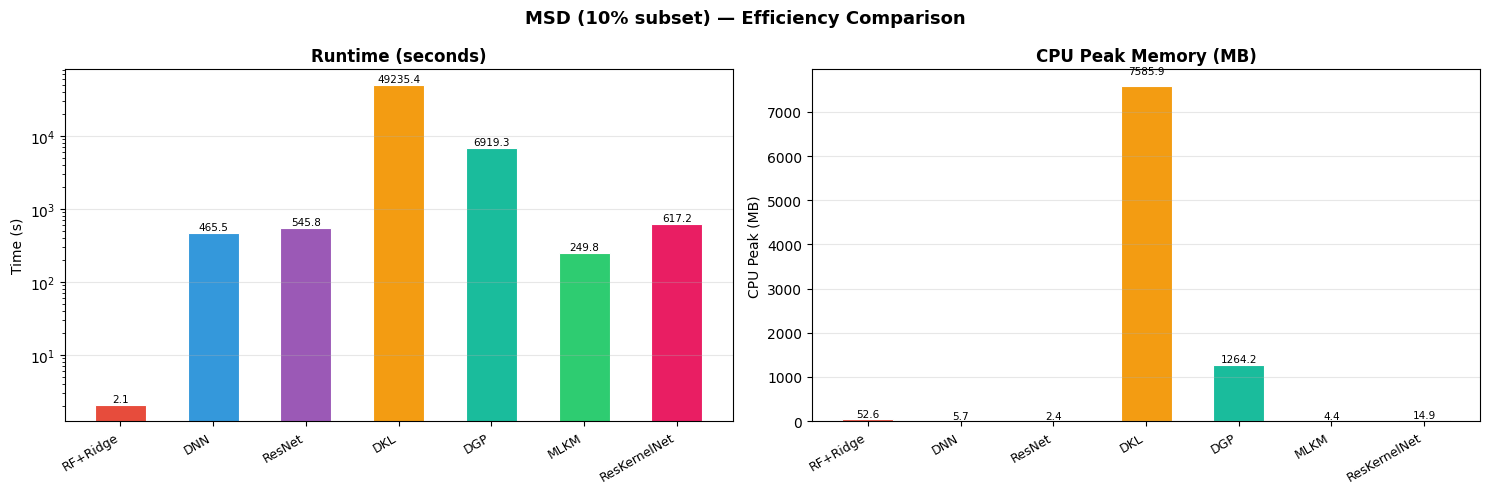

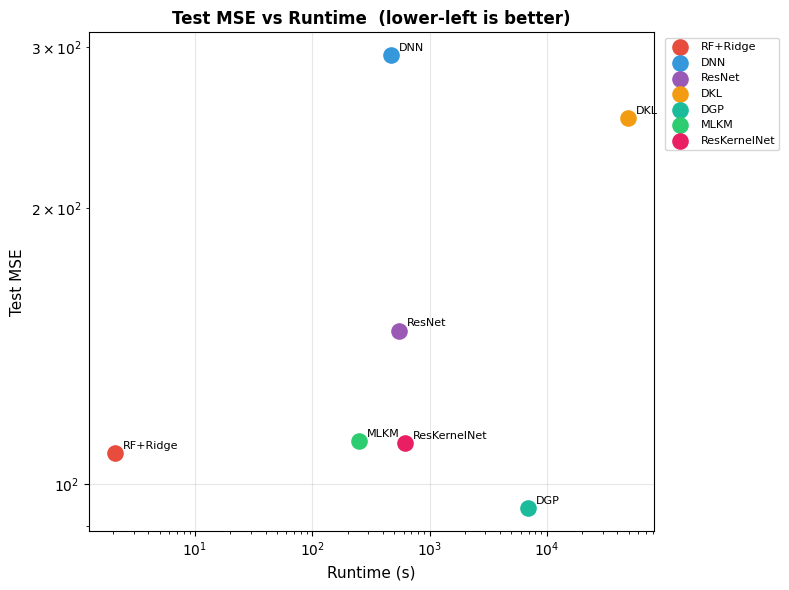

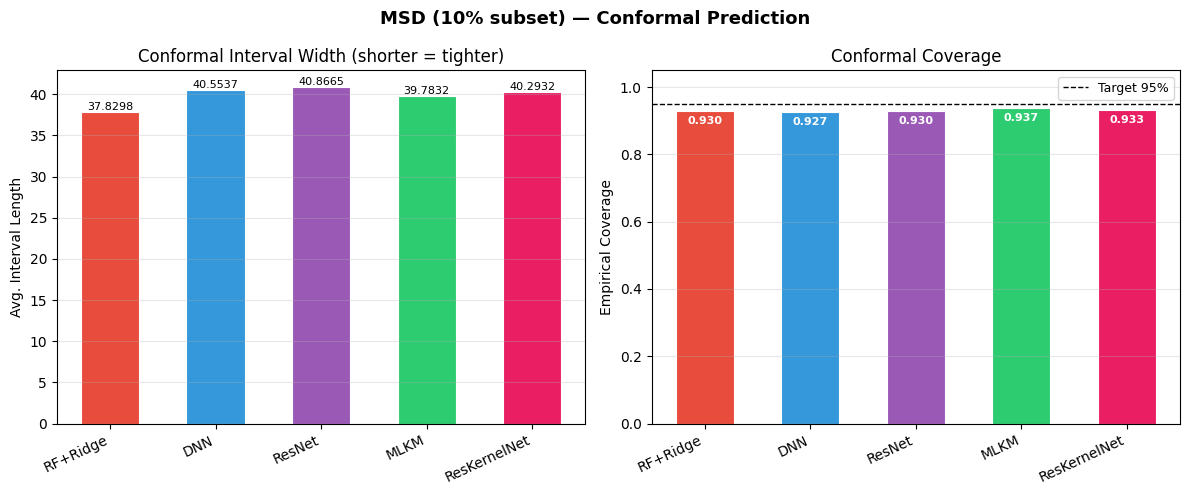

Saved all figures to msd_results_10pct/


In [46]:
# ── Result Visualisation (4 figures) ─────────────────────────────────────────
methods  = results_df.index.tolist()
colors   = ['#e74c3c','#3498db','#9b59b6','#f39c12','#1abc9c','#2ecc71','#e91e63']
x        = np.arange(len(methods))
bar_w    = 0.55

# ── Fig 1: Test MSE + Train MSE ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, title in [
    (axes[0], 'Test MSE',  'Test MSE by Method'),
    (axes[1], 'Train MSE', 'Train MSE by Method'),
]:
    vals = results_df[col].values
    bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(col); ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('MSD (10% subset) — MSE Comparison (lower is better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_mse_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: Runtime + CPU Peak Memory ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, title, logy in [
    (axes[0], 'Time (s)',      'Runtime (seconds)',    True),
    (axes[1], 'CPU Peak (MB)', 'CPU Peak Memory (MB)', False),
]:
    vals = results_df[col].values
    bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(col); ax.set_title(title, fontsize=12, fontweight='bold')
    if logy: ax.set_yscale('log')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.03,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('MSD (10% subset) — Efficiency Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_efficiency.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 3: Scatter — Test MSE vs Runtime ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for i, m in enumerate(methods):
    ax.scatter(results_df.loc[m,'Time (s)'], results_df.loc[m,'Test MSE'],
               color=colors[i], s=120, zorder=5, label=m)
    ax.annotate(m, (results_df.loc[m,'Time (s)'], results_df.loc[m,'Test MSE']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Runtime (s)', fontsize=11); ax.set_ylabel('Test MSE', fontsize=11)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Test MSE vs Runtime  (lower-left is better)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_mse_vs_time.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: Conformal Coverage & Interval ─────────────────────────────────────
_cf_df = results_df[['Conf. Coverage', 'Conf. Interval']].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cf_methods = _cf_df.index.tolist()
cf_colors  = [colors[methods.index(m)] for m in cf_methods]
xc = np.arange(len(cf_methods))

axes[0].bar(xc, _cf_df['Conf. Interval'].values, width=bar_w,
            color=cf_colors, edgecolor='white', linewidth=0.8)
for v, xi in zip(_cf_df['Conf. Interval'].values, xc):
    axes[0].text(xi, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xc); axes[0].set_xticklabels(cf_methods, rotation=25, ha='right')
axes[0].set_ylabel('Avg. Interval Length')
axes[0].set_title('Conformal Interval Width (shorter = tighter)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(xc, _cf_df['Conf. Coverage'].values, width=bar_w,
            color=cf_colors, edgecolor='white', linewidth=0.8)
axes[1].axhline(0.95, color='k', ls='--', lw=1, label='Target 95%')
for v, xi in zip(_cf_df['Conf. Coverage'].values, xc):
    axes[1].text(xi, v - 0.015, f'{v:.3f}', ha='center', va='top', fontsize=8,
                 color='white', fontweight='bold')
axes[1].set_xticks(xc); axes[1].set_xticklabels(cf_methods, rotation=25, ha='right')
axes[1].set_ylabel('Empirical Coverage')
axes[1].set_title('Conformal Coverage')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('MSD (10% subset) — Conformal Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_conformal.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved all figures to {RESULTS_DIR}/')

---
## D-Sensitivity Analysis: MLKM & ResKernelNet

Compare D ∈ {64, 128, 256} for both MLKM and ResKernelNet.  
All other hyperparameters fixed. Per-layer gammas recomputed for each D.

In [28]:
# ── D-Sensitivity: run MLKM and ResKernelNet for D in {64, 128, 256} ─────────
D_VALUES = [64, 128, 256]

d_results = {
    'MLKM':         {D: {} for D in D_VALUES},
    'ResKernelNet': {D: {} for D in D_VALUES},
}

for D in D_VALUES:
    print(f'\n{"="*55}')
    print(f'  D = {D}')
    print(f'{"="*55}')

    # ── MLKM ──────────────────────────────────────────────────
    print(f'  [MLKM] pre-computing gammas for D={D}...')
    _g1 = _compute_layer_gamma(train_x)
    with torch.no_grad():
        _r1 = RandomFourierFeature(INPUT_DIM, D, kernel='G', gamma=_g1)
        _f1 = nn.Linear(D, HIDDEN_DIM1)
        _h1 = _f1(_r1.transform(torch.from_numpy(train_x).float())).numpy()
    _g2 = _compute_layer_gamma(_h1)
    with torch.no_grad():
        _r2 = RandomFourierFeature(HIDDEN_DIM1, D, kernel='G', gamma=_g2)
        _f2 = nn.Linear(D, HIDDEN_DIM2)
        _h2 = _f2(_r2.transform(torch.from_numpy(_h1).float())).numpy()
    _g3 = _compute_layer_gamma(_h2)
    _gammas_mlkm = (_g1, _g2, _g3)
    print(f'         gammas: L1={_g1:.4f}  L2={_g2:.4f}  L3={_g3:.4f}')
    del _r1, _r2, _f1, _f2, _h1, _h2

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    def _mlkm_d():
        return run_mlkm(train_x, train_y, test_x, test_y,
                        D1=D, D2=D, D3=D,
                        gammas=_gammas_mlkm, **TRAINING_CONFIG)

    (mlkm_r, _, _), t = measure_time(lambda: measure_memory_cpu(_mlkm_d))
    tr_mse, te_mse, ep, _, _, trl, tel, _ = mlkm_r
    d_results['MLKM'][D] = {
        'train_mse': tr_mse, 'test_mse': te_mse,
        'epochs': ep, 'time': t,
        'trainloss': trl, 'testloss': tel,
    }
    print(f'  [MLKM]  D={D:3d}  train={tr_mse:.5f}  test={te_mse:.5f}  ep={ep}  t={t:.1f}s')

    # ── ResKernelNet ──────────────────────────────────────────
    print(f'  [RKN]  pre-computing gammas for D={D}...')
    _g1 = _compute_layer_gamma(train_x)
    with torch.no_grad():
        _r1   = RandomFourierFeature(INPUT_DIM, D, kernel='G', gamma=_g1)
        _A1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
        _W1   = nn.Linear(D, HIDDEN_DIM1)
        _D1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False); nn.init.zeros_(_D1.weight)
        _xt   = torch.from_numpy(train_x).float()
        _h1   = (_A1(_xt) + _D1(_xt) + _W1(_r1.transform(_xt))).numpy()
    _g2 = _compute_layer_gamma(_h1)
    with torch.no_grad():
        _r2   = RandomFourierFeature(HIDDEN_DIM1, HIDDEN_DIM1, kernel='G', gamma=_g2)
        _A2   = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                 if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
        _W2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
        _D2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False); nn.init.zeros_(_D2.weight)
        _h1t  = torch.from_numpy(_h1).float()
        _h2   = (_A2(_h1t) + _D2(_h1t) + _W2(_r2.transform(_h1t))).numpy()
    _g3 = _compute_layer_gamma(_h2)
    _gammas_rkn = (_g1, _g2, _g3)
    print(f'         gammas: L1={_g1:.4f}  L2={_g2:.4f}  L3={_g3:.4f}')
    del _r1, _r2, _A1, _A2, _W1, _W2, _D1, _D2, _h1, _h2, _xt, _h1t

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # D2=HIDDEN_DIM1, D3=HIDDEN_DIM2 (residual constraint); only D1 varies
    def _rkn_d():
        return run_reskernelnet(train_x, train_y, test_x, test_y,
                                D1=D,
                                gammas=_gammas_rkn, **TRAINING_CONFIG)

    (rkn_r, _, _), t = measure_time(lambda: measure_memory_cpu(_rkn_d))
    tr_mse, te_mse, ep, _, _, trl, tel, _ = rkn_r
    d_results['ResKernelNet'][D] = {
        'train_mse': tr_mse, 'test_mse': te_mse,
        'epochs': ep, 'time': t,
        'trainloss': trl, 'testloss': tel,
    }
    print(f'  [RKN]   D={D:3d}  train={tr_mse:.5f}  test={te_mse:.5f}  ep={ep}  t={t:.1f}s')

print('\nDone.')


  D = 64
  [MLKM] pre-computing gammas for D=64...
         gammas: L1=0.0917  L2=0.9039  L3=1.4031
  [MLKM]  D= 64  train=79.69198  test=109.77808  ep=681  t=346.8s
  [RKN]  pre-computing gammas for D=64...
         gammas: L1=0.0917  L2=0.0943  L3=0.2337
  [RKN]   D= 64  train=89.70462  test=108.09119  ep=679  t=567.3s

  D = 128
  [MLKM] pre-computing gammas for D=128...
         gammas: L1=0.0917  L2=1.3882  L3=1.9605
  [MLKM]  D=128  train=55.69715  test=108.71780  ep=1000  t=610.3s
  [RKN]  pre-computing gammas for D=128...
         gammas: L1=0.0917  L2=0.0935  L3=0.2332
  [RKN]   D=128  train=92.01517  test=110.92660  ep=647  t=598.2s

  D = 256
  [MLKM] pre-computing gammas for D=256...
         gammas: L1=0.0917  L2=1.9304  L3=2.7157
  [MLKM]  D=256  train=52.48123  test=113.75936  ep=865  t=700.8s
  [RKN]  pre-computing gammas for D=256...
         gammas: L1=0.0917  L2=0.0949  L3=0.2358
  [RKN]   D=256  train=89.13204  test=105.46684  ep=844  t=848.6s

Done.


In [29]:
# ── D-Sensitivity Summary Table ──────────────────────────────────────────────
rows = []
for method in ['MLKM', 'ResKernelNet']:
    for D in D_VALUES:
        r = d_results[method][D]
        rows.append({
            'Method': method,
            'D': D,
            'Train MSE': r['train_mse'],
            'Test MSE':  r['test_mse'],
            'Epochs':    r['epochs'],
            'Time (s)':  r['time'],
        })

d_df = pd.DataFrame(rows)
print('=' * 65)
print('  D-Sensitivity: MLKM & ResKernelNet  (MSD 10% subset)')
print('=' * 65)
print(d_df.to_string(index=False, float_format=lambda x: f'{x:.5f}'))

d_df.to_csv(os.path.join(RESULTS_DIR, 'd_sensitivity_table.csv'), index=False)
print(f'\nSaved -> {RESULTS_DIR}/d_sensitivity_table.csv')

  D-Sensitivity: MLKM & ResKernelNet  (MSD 10% subset)
      Method   D  Train MSE  Test MSE  Epochs  Time (s)
        MLKM  64   79.69198 109.77808     681 346.76119
        MLKM 128   55.69715 108.71780    1000 610.26607
        MLKM 256   52.48123 113.75936     865 700.81616
ResKernelNet  64   89.70462 108.09119     679 567.33075
ResKernelNet 128   92.01517 110.92660     647 598.21302
ResKernelNet 256   89.13204 105.46684     844 848.58232

Saved -> msd_results_10pct/d_sensitivity_table.csv


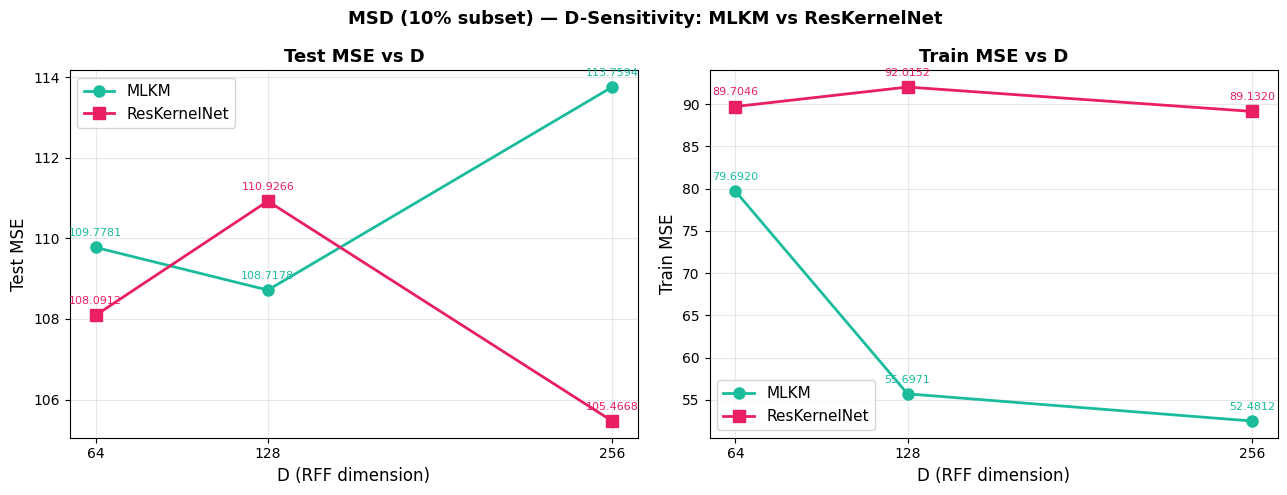

Saved -> msd_results_10pct/fig5_d_sensitivity.png


In [30]:
# ── D-Sensitivity Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_styles = {
    'MLKM':         {'color': '#1abc9c', 'marker': 'o'},
    'ResKernelNet': {'color': '#e91e63', 'marker': 's'},
}

for ax, metric, ylabel, title in [
    (axes[0], 'Test MSE',  'Test MSE',  'Test MSE vs D'),
    (axes[1], 'Train MSE', 'Train MSE', 'Train MSE vs D'),
]:
    for method, style in method_styles.items():
        vals = [d_results[method][D][metric.lower().replace(' ', '_')] for D in D_VALUES]
        ax.plot(D_VALUES, vals,
                marker=style['marker'], color=style['color'],
                linewidth=2, markersize=8, label=method)
        for D, v in zip(D_VALUES, vals):
            ax.annotate(f'{v:.4f}', (D, v),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8, color=style['color'])
    ax.set_xlabel('D (RFF dimension)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(D_VALUES)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('MSD (10% subset) — D-Sensitivity: MLKM vs ResKernelNet',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_d_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {RESULTS_DIR}/fig5_d_sensitivity.png')

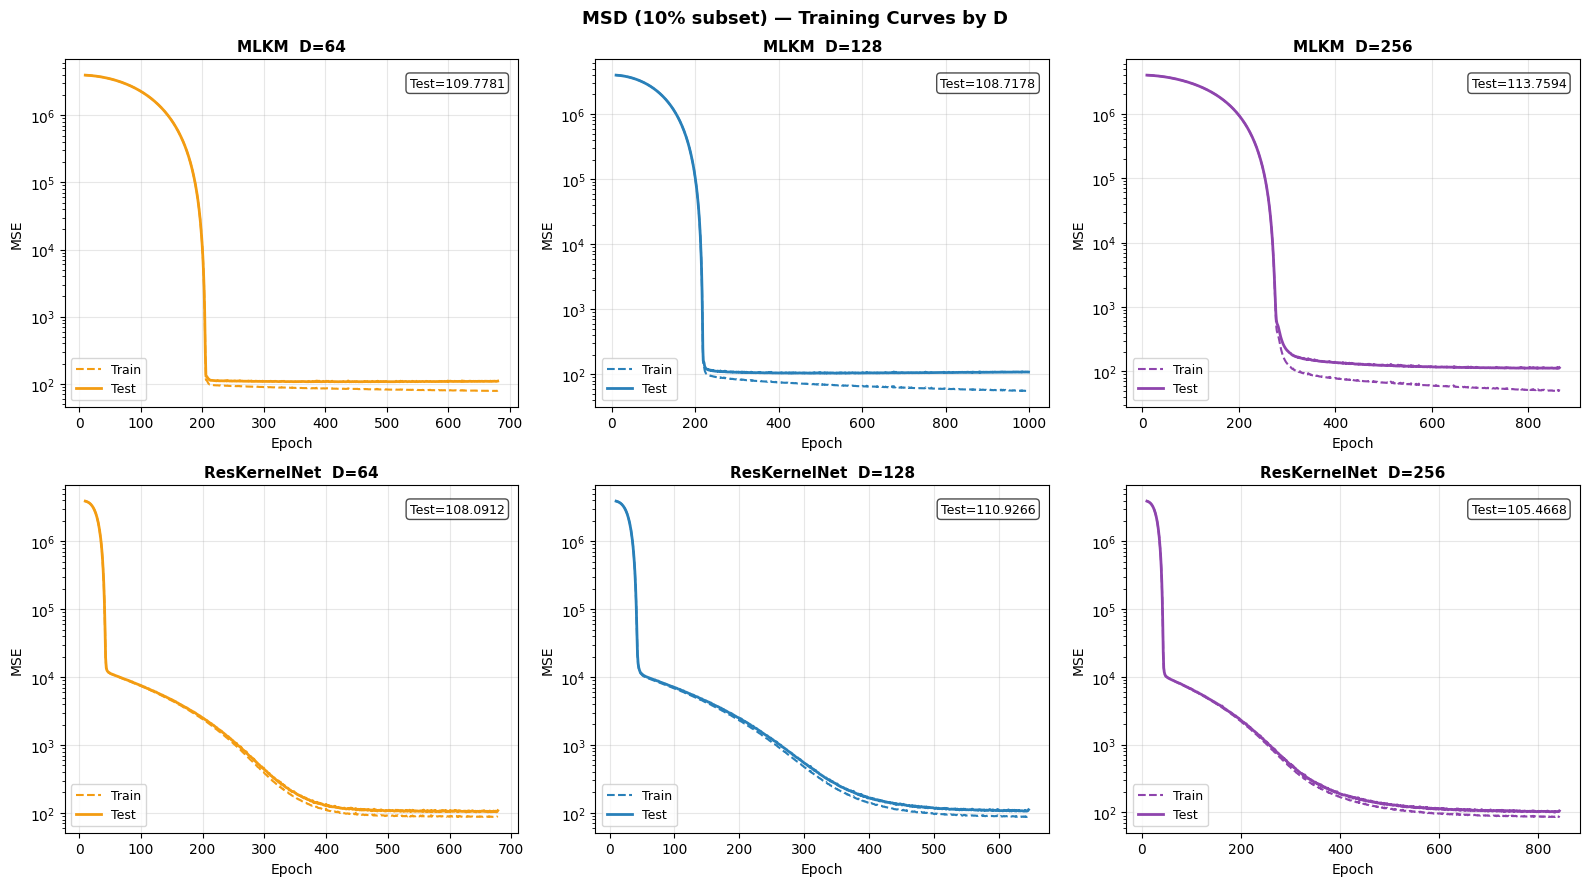

Saved -> msd_results_10pct/fig6_d_training_curves.png


In [31]:
# ── Training Curves for each D ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
skip = 10

d_colors = {64: '#f39c12', 128: '#2980b9', 256: '#8e44ad'}

for row_idx, method in enumerate(['MLKM', 'ResKernelNet']):
    for col_idx, D in enumerate(D_VALUES):
        ax = axes[row_idx][col_idx]
        r  = d_results[method][D]
        ep = range(skip, len(r['testloss']))
        ax.plot(ep, r['trainloss'][skip:], color=d_colors[D], ls='--', lw=1.5, label='Train')
        ax.plot(ep, r['testloss'][skip:],  color=d_colors[D], ls='-',  lw=2,   label='Test')
        ax.set_title(f'{method}  D={D}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.set_yscale('log'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.95, f'Test={r["test_mse"]:.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('MSD (10% subset) — Training Curves by D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig6_d_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {RESULTS_DIR}/fig6_d_training_curves.png')